[INFO] loading images...
[INFO] compiling model...
[INFO] training head...
Epoch 1/20
84/84 [==============================] - 132s 2s/step - loss: 0.7749 - accuracy: 0.5495 - val_loss: 0.6815 - val_accuracy: 0.5778
Epoch 2/20
84/84 [==============================] - 127s 2s/step - loss: 0.6367 - accuracy: 0.6462 - val_loss: 0.6179 - val_accuracy: 0.6459
Epoch 3/20
84/84 [==============================] - 127s 2s/step - loss: 0.5975 - accuracy: 0.6758 - val_loss: 0.5917 - val_accuracy: 0.6815
Epoch 4/20
84/84 [==============================] - 125s 1s/step - loss: 0.5835 - accuracy: 0.6930 - val_loss: 0.5721 - val_accuracy: 0.7037
Epoch 5/20
84/84 [==============================] - 127s 2s/step - loss: 0.5629 - accuracy: 0.7114 - val_loss: 0.5759 - val_accuracy: 0.7081
Epoch 6/20
84/84 [==============================] - 126s 1s/step - loss: 0.5466 - accuracy: 0.7219 - val_loss: 0.5394 - val_accuracy: 0.7230
Epoch 7/20
84/84 [==============================] - 126s 1s/step - loss: 0.5187

C:\Users\jegat\Anaconda3\envs\deep_learning\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


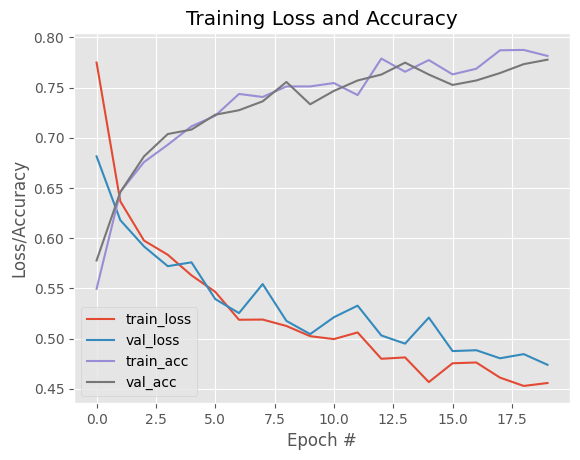

In [1]:
# USAGE
# python train_emotion_detector.py --dataset dataset

# import the necessary packages
import tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
#from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import argparse
import os


# construct the argument parser and parse the arguments
ap = argparse.ArgumentParser()

ap.add_argument("-d", "--dataset", type=str,
    default="dataset",
    help="path to input dataset")

ap.add_argument("-p", "--plot", type=str,
    default="plot.png",
    help="path to output loss/accuracy plot")

ap.add_argument("-m", "--model", type=str,
    default="emotion_detector.model",
    help="path to output face emotion detector model")

args = vars(ap.parse_args(args=[]))

# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-4
EPOCHS = 20
BS = 32


# grab the list of images in our dataset directory, then initialize
# the list of data (i.e., images) and class images
print("[INFO] loading images...")
imagePaths = list(paths.list_images(args["dataset"]))
data = []
labels = []


# loop over the image paths
for imagePath in imagePaths:
	# extract the class label from the filename
	label = imagePath.split(os.path.sep)[-2]

	# load the input image (224x224) and preprocess it
	image = load_img(imagePath, target_size=(224, 224))
	image = img_to_array(image)
	image = preprocess_input(image)

	# update the data and labels lists, respectively
	data.append(image)
	labels.append(label)

# convert the data and labels to NumPy arrays
data = np.array(data, dtype="float32")
labels = np.array(labels)


# perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = to_categorical(labels)

# partition the data into training and testing splits using 75% of
# the data for training and the remaining 25% for testing
(trainX, testX, trainY, testY) = train_test_split(data, labels,
	test_size=0.20, stratify=labels, random_state=42)

# construct the training image generator for data augmentation
aug = ImageDataGenerator(
	rotation_range=15,
	zoom_range=0.15,
	width_shift_range=0.2,
	height_shift_range=0.2,
	shear_range=0.15,
	horizontal_flip=True,
   	fill_mode="nearest")

# load the MobileNetV2 network, ensuring the head FC layer sets are
# left off
baseModel =ResNet50(weights="imagenet", include_top=False,
input_tensor=Input(shape=(224, 224, 3)))
# construct the head of the model that will be placed on top of the
# the base model

headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
#headModel = GlobalAveragePooling2D()(headModel)
headModel = Flatten(name="flatten")(headModel)
#headModel = Dense(512, activation="relu")(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.4)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


# place the head FC model on top of the base model (this will become
# the actual model we will train)
model = Model(inputs=baseModel.input, outputs=headModel)

# loop over all layers in the base model and freeze them so they will
# *not* be updated during the first training process
for layer in baseModel.layers:
	layer.trainable = False
#for layer in baseModel.layers[-30:]:
	#layer.trainable = True
    

# compile our model
print("[INFO] compiling model...")
opt =tensorflow.keras.optimizers.Adam(learning_rate=INIT_LR)
model.compile(loss="categorical_crossentropy", optimizer=opt,
	           metrics=["accuracy"])


# train the head of the network
print("[INFO] training head...") 
#class_weight={0: 1.5,1: 1.0}
H = model.fit(
	aug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS)
    
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)

# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)

# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

# serialize the model to disk
print("[INFO] saving emotion detector model...")
model.save(args["model"], save_format="h5")

# plot the training loss and accuracy
N = EPOCHS
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
plt.savefig(args["plot"])


In [2]:
#Chech the path
print(os.path.exists(args["dataset"]))

True


In [4]:
print(trainY.shape)

(2684, 2)


In [3]:
print(model.output_shape)

(None, 2)
